#### Evaluation

##### Importing Libraries and Loading Data

In [1]:
import os

from IPython.lib.pretty import signature

os.environ['OMP_NUM_THREADS'] = '2'

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
processed_dir = project_root/'data'/'processed'
figures_dir = project_root/'reports'/'figures'


In [3]:
features = pd.read_parquet(processed_dir/'station_clusters_full.parquet')
features_scaled = pd.read_parquet(processed_dir/'station_features_scaled.parquet')
long = pd.read_parquet(processed_dir/'station_time.parquet')

In [4]:
features.columns

Index(['log_total_weekday', 'early_share', 'eve_share', 'late_share',
       'peakness', 'am_asym', 'pm_asym', 'weekend_shift', 'weekend_ratio',
       'lines_served', 'interchange_ratio', 'cluster_k', 'cluster_hier',
       'cluster_dbscan', 'station_name'],
      dtype='str')

##### Bootstrap Stability

In [5]:
# Checking Bootstrap Stability for validation

X = features_scaled.values

In [21]:
print ('K | Silhouette | Stability')
for k in [4, 5, 6, 7]:
    base_labels = KMeans(n_clusters=k, n_init=10, random_state=69).fit_predict(X)
    sil = silhouette_score(X, base_labels)

    rng = np.random.RandomState(0)
    scores = []
    for i in range(30):
        idx = rng.choice(len(X), size=len(X), replace=True)
        boots_labels = KMeans(n_clusters=k, n_init=10, random_state=1).fit_predict(X[idx])
        scores.append(adjusted_rand_score(base_labels[idx], boots_labels))

    print(f'{k} | {sil:.2f} | {np.mean(scores):.2f}')

K | Silhouette | Stability
4 | 0.31 | 0.89
5 | 0.31 | 0.75
6 | 0.25 | 0.69
7 | 0.23 | 0.73


##### Centroids

In [7]:
features_cols = [
    'log_total_weekday', 'early_share', 'eve_share', 'late_share',
       'peakness', 'am_asym', 'pm_asym', 'weekend_shift', 'weekend_ratio',
       'lines_served', 'interchange_ratio',
]

In [8]:
# Average each feature per cluster

centroids = features.groupby('cluster_k')[features_cols].mean()

In [9]:
# Adding number of stations in each cluster

centroids['cluster_size'] = features['cluster_k'].value_counts().sort_index()

In [10]:
centroids.T.round(2)

cluster_k,0,1,2,3,4,5
log_total_weekday,8.27,9.72,9.54,8.66,10.56,9.40
early_share,0.12,0.05,0.07,0.06,0.01,0.02
eve_share,0.04,0.10,0.07,0.09,0.19,0.15
late_share,0.01,0.04,0.03,0.03,0.10,0.07
peakness,0.05,0.04,0.04,0.03,0.04,0.04
am_asym,0.56,0.15,0.34,0.19,-0.53,-0.47
pm_asym,-0.41,-0.07,-0.24,-0.07,0.23,0.28
weekend_shift,0.34,0.23,0.29,0.25,0.16,0.18
weekend_ratio,0.72,0.86,0.81,0.83,0.94,0.77
lines_served,1.07,2.45,1.60,1.11,2.83,1.41


##### Average Daily Profile

In [11]:
# 15m Quarter Hour columns in order

qcols = sorted(long['quarter_hour'].unique(), key=lambda c: (c[:2] < '05', c))

In [12]:
profiles = (
    long[(long['daytype'] == 'twt') & (long['metric'] == 'entries')]
    .pivot_table(index='nlc', columns='quarter_hour', values='count')[qcols]
)

In [13]:
profiles.head()

quarter_hour,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
nlc,,,,,,,,,,,,,,,,,,,,,
500,10.216430,17.043676,28.687394,43.210581,57.887766,72.986687,96.543168,123.143127,152.749742,192.346564,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.462876,6.462876,6.462876
501,1.608785,2.493975,3.173810,5.519258,7.119713,12.054720,15.986622,21.553983,27.272648,34.812441,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
502,3.880963,4.875753,10.066814,17.149131,28.670477,42.795930,61.966981,78.429382,97.434879,110.690478,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
503,6.577514,10.629400,16.354996,24.661014,34.283967,41.712095,54.100766,71.777687,92.469163,111.728368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
504,3.075486,6.077870,11.453846,24.607448,35.645008,44.168136,67.518830,83.685305,100.185009,120.832802,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [14]:
profiles.shape

(471, 96)

In [15]:
# Normalizing because we want shape not size

profiles = profiles.div(profiles.sum(axis=1), axis=0)

In [16]:
# Attaching Cluster Labels
profiles = profiles.join(features['cluster_k'])

In [17]:
profiles.head()

,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,...,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500,cluster_k
nlc,,,,,,,,,,,,,,,,,,,,,
500,0.001243,0.002073,0.003489,0.005256,0.007041,0.008878,0.011743,0.014978,0.018580,0.023396,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000786,0.000786,0.000786,1.0
501,0.000161,0.000250,0.000318,0.000552,0.000712,0.001206,0.001600,0.002157,0.002729,0.003483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,5.0
502,0.000295,0.000371,0.000766,0.001305,0.002182,0.003257,0.004716,0.005969,0.007415,0.008424,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,5.0
503,0.000317,0.000512,0.000787,0.001187,0.001650,0.002008,0.002604,0.003455,0.004451,0.005378,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,2.0
504,0.000455,0.000899,0.001694,0.003639,0.005271,0.006531,0.009984,0.012374,0.014814,0.017867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,3.0


In [18]:
# Typical day for each type

cluster_profiles = profiles.groupby('cluster_k').mean()

In [19]:
cluster_profiles

,0500-0515,0515-0530,0530-0545,0545-0600,0600-0615,0615-0630,0630-0645,0645-0700,0700-0715,0715-0730,...,0230-0245,0245-0300,0300-0315,0315-0330,0330-0345,0345-0400,0400-0415,0415-0430,0430-0445,0445-0500
cluster_k,,,,,,,,,,,,,,,,,,,,,
0.0,0.002517,0.004964,0.008505,0.012622,0.016414,0.021193,0.025168,0.029514,0.033861,0.040447,...,4.410255e-08,3.779474e-08,4.810464e-09,1.180502e-07,6.427361e-07,1.120712e-06,1.354502e-06,0.000064,0.000064,0.000064
1.0,0.001064,0.001925,0.003174,0.005050,0.006874,0.008906,0.011262,0.013708,0.016064,0.018905,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.745399e-05,0.000058,0.000058,0.000058
2.0,0.001218,0.002444,0.004401,0.006882,0.009646,0.012818,0.016554,0.020014,0.024207,0.028816,...,1.810004e-08,2.255020e-08,1.817334e-07,1.856514e-07,1.798396e-07,7.185125e-07,6.368985e-06,0.000056,0.000056,0.000056
3.0,0.000955,0.001906,0.003478,0.005526,0.007691,0.010113,0.012773,0.015349,0.018023,0.021357,...,7.356938e-12,1.946420e-08,2.004419e-08,2.131826e-08,3.775331e-07,5.259683e-07,5.122449e-06,0.000018,0.000018,0.000018
4.0,0.000153,0.000289,0.000571,0.001015,0.001491,0.002040,0.002792,0.003646,0.004484,0.005635,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.754431e-13,0.000003,0.000003,0.000003
5.0,0.000287,0.000564,0.001050,0.001718,0.002396,0.003185,0.004148,0.005161,0.006190,0.007504,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.339058e-07,0.000024,0.000024,0.000024


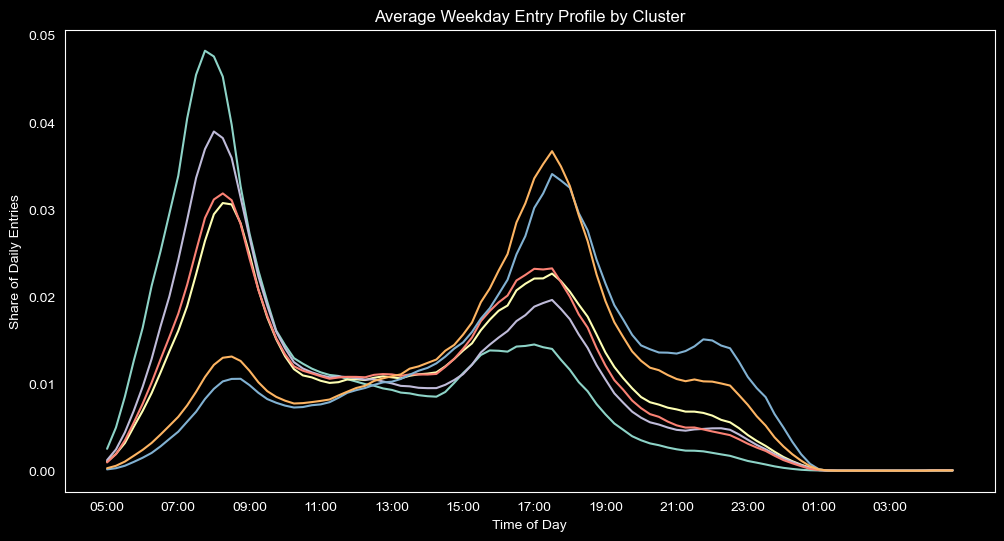

In [32]:
plt.figure(figsize=(12, 6))

for c in cluster_profiles.index:
    plt.plot(range(len(qcols)), cluster_profiles.loc[c], label=f'Cluster {c}')

# A tick every 2 hours or every 8 quarter hours
tick_positions = range(0, len(qcols), 8)

# Label each tick with the Hour
tick_labels = [qcols[i][:2] + ':00' for i in tick_positions]

plt.xticks(tick_positions, tick_labels)
plt.xlabel('Time of Day')
plt.ylabel('Share of Daily Entries')
plt.title('Average Weekday Entry Profile by Cluster')


plt.grid(False)
plt.savefig(figures_dir/'cluster_profiles.png', dpi=120)

plt.show()

In [34]:
# Using features for assigning names

signature = features.groupby('cluster_k')[
    ['log_total_weekday', 'am_asym', 'interchange_ratio', 'lines_served']
].mean()

In [36]:
signature.round(2)

,log_total_weekday,am_asym,interchange_ratio,lines_served
cluster_k,,,,
0,8.27,0.56,0.00,1.07
1,9.72,0.15,0.71,2.45
2,9.54,0.34,0.26,1.60
3,8.66,0.19,0.01,1.11
4,10.56,-0.53,0.45,2.83
5,9.40,-0.47,0.01,1.41


In [42]:
# Assigning Names to the clusters

names = {}
remaining = set(signature.index)

def assign(metric, how, label):
    pool = signature.loc[sorted(remaining), metric]
    cid = pool.idxmax() if how == 'max' else pool.idxmin()
    names[cid] = label
    remaining.discard(cid)

assign('interchange_ratio', 'max', 'Outer Transfer Hubs')
assign('log_total_weekday', 'max', 'Central Mega-Interchanges')
assign('am_asym', 'max', 'Outer Residential Origins')
assign('am_asym', 'min', 'Central Workplace Destinations')
assign('lines_served', 'max', 'Busy Commuter Interchanges')
names[remaining.pop()] = 'Inner Local Stations'

features['archetype'] = features['cluster_k'].map(names)

In [45]:
features.head()

,log_total_weekday,early_share,eve_share,late_share,peakness,am_asym,pm_asym,weekend_shift,weekend_ratio,lines_served,interchange_ratio,cluster_k,cluster_hier,cluster_dbscan,station_name,archetype
nlc,,,,,,,,,,,,,,,,
750,7.760586,0.077621,0.094472,0.041111,0.030217,0.139383,-0.006690,0.213420,0.783216,1,0.000000,3,3,0,Abbey Road,Inner Local Stations
1404,7.923830,0.071789,0.080898,0.027622,0.036185,0.116857,-0.139332,0.267944,0.725684,1,0.000000,3,3,0,Acton Central,Inner Local Stations
3000,8.666488,0.072965,0.052739,0.012879,0.043083,0.420971,-0.182355,0.291676,0.847376,1,0.000000,3,4,0,Acton Main Line,Inner Local Stations
500,9.014619,0.054701,0.059517,0.020899,0.040084,0.274624,-0.098968,0.242156,0.812725,2,0.609405,1,6,-1,Acton Town,Outer Transfer Hubs
502,9.483445,0.018862,0.125731,0.043576,0.049968,-0.556020,0.334524,0.255896,0.527519,2,0.025067,5,2,0,Aldgate,Central Workplace Destinations


In [46]:
features['archetype'].value_counts()

archetype
Inner Local Stations              157
Outer Residential Origins         138
Central Workplace Destinations     59
Busy Commuter Interchanges         40
Outer Transfer Hubs                20
Central Mega-Interchanges          18
Name: count, dtype: int64

In [47]:
# Saving
features.to_parquet(processed_dir/'station_archetypes.parquet')